# Forward-modeling simulation histories: photometry and lines, fast

You have a simulation. For each galaxy it gives you a star formation history
and a metallicity history — arrays, not parameters. You want broadband
photometry and emission-line fluxes for all of them, as fast as possible.

That is all this notebook does.

```text
    in :  t [Gyr]        (n_t,)      cosmic time, shared or per galaxy
          SFR(t)         (N, n_t)    M☉/yr
          Z(t)           (N, n_t)    stellar metallicity
    out:  photometry     (N, n_β)    erg/s/cm2/Hz
          line fluxes    (N,)  each  erg/s/cm2
          properties     (N,)  each  stellar mass, SFR, ...
```

There is no fitting here and **no free parameters** — the tables are the
model. Sections 1–3 are the working code; sections 4–5 are the speed, which
is the part worth reading twice.

In [1]:
from _setup import FIG_DIR, quiet

quiet()

import gc
import resource
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np

import jax

import tengri
from tengri import (
    FIXED,
    Catalog,
    Fixed,
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    WavePrecomp,
    plot,
)
from tengri.utils.cosmology import age_at_z

plot.setup_style()
print(f"JAX backend: {jax.devices()[0].platform}   x64: {jax.config.jax_enable_x64}")

JAX backend: cpu   x64: True


## 1. The model

Four choices set the speed. Section 5 measures the cost of each choice.

In [2]:
Z_OBS = 0.1  # snapshot redshift
T_OBS = float(age_at_z(Z_OBS))  # age of the universe there [Gyr]

# wNE = "with nebular emission": lines and nebular continuum are baked into the
# SSP templates. This is the fast configuration AND the one that gives you
# emission lines — see section 3.
ssp = tengri.load_ssp("prsc_miles_chabrier_wNE", download=True)

BANDS = [f"sdss_{b}" for b in "ugriz"] + [f"lsst_{b}" for b in "ugrizy"]
phot = Photometry.from_names(BANDS)


PRECOMP = WavePrecomp()  # the SSP x filter lookup table; see section 5b


def build_model(approx=PRECOMP, neb=None):
    """The forward operator. Defaults are the fast configuration.

    Pass ``approx=None`` for the exact wavelength-grid path (section 5b).
    """
    sed = SEDModel.build(
        ssp_data=ssp,
        observation=Observation(photometry=phot),
        redshift=Fixed(Z_OBS),
        sfh={"type": "table"},  # SFH arrives at runtime, as data
        met={"type": "table"},  # so does the stellar metallicity
        dust_attenuation={"type": "two_component", "law": "calzetti", "*": FIXED},
        neb=neb or {"type": "ssp"},  # baked into the SSP: zero per-galaxy cost
        approx=approx,  # SSP x filter LUT, or None for the exact path
    )
    return ForwardModel.build(sed=sed)


fwd = build_model()
print(f"{phot.n_filters} bands   free parameters: {fwd.spec.free_params}")

src/tengri/components/stellar/sps/dsps_wrapper.py:354: UserWarning: 'ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5' is a wNE (with-Nebular-Emission) SSP: nebular continuum and lines are already baked into the templates at fixed logU/logZ_gas. Pair it with the default baked-in nebular backend only — adding neb={'type': 'cue'} or a CLOUDY grid on top double-counts nebular emission.
  return load_ssp_data(str(candidate))


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_89400/722251314.py:21: DefaultFixedParametersWarning: Group 'met' states no 'all_params' disposition, so its remaining parameter was fixed at declared defaults:
  met_alpha_fe=0

To fit them, pass 'all_params': FREE:
  met={'all_params': FREE, ...}
To keep them fixed and silence this warning, say so explicitly:
  met={'all_params': FIXED, ...}
  sed = SEDModel.build(


11 bands   free parameters: []


## 2. The histories

Replace `simulation_snapshot` with your reader. Only three things matter:
the shapes, the units, and `met_unit=` — declare it, because `Z = 2e-4` is a
legal value both as a mass fraction and as log10(Z/Z☉), and reading one as
the other is a silent factor of ~70.

In [3]:
N_T = 96


def simulation_snapshot(n_galaxies, seed=11):
    """Stand-in for your snapshot reader: t [Gyr], SFR [Msun/yr], Z (mass fraction).

    A spread of masses, formation times and decay timescales, with metallicity
    rising as gas turns into stars. The shape of this mock is not the point.
    """
    rng = np.random.default_rng(seed)
    log_mass = rng.uniform(8.5, 11.5, n_galaxies)
    t_form = rng.uniform(0.3, 4.0, n_galaxies)
    tau = 10 ** rng.uniform(-0.3, 0.95, n_galaxies)

    t_gyr = np.linspace(0.05, T_OBS, N_T)
    since = np.clip(t_gyr[None, :] - t_form[:, None], 0.0, None)
    sfr = (since / tau[:, None]) * np.exp(-since / tau[:, None])
    dt_yr = np.gradient(t_gyr) * 1e9
    sfr *= (10**log_mass / (sfr * dt_yr[None, :]).sum(axis=1))[:, None]

    formed_fraction = np.cumsum(sfr * dt_yr[None, :], axis=1) / (10**log_mass)[:, None]
    met = 0.02 * np.log(1.0 / (1.0 - 0.7 * formed_fraction))
    return dict(t_gyr=t_gyr, sfr=sfr, met=met, log_mass=log_mass)


snap = simulation_snapshot(500)

# Simulations go below the SSP grid's lowest metallicity node at early times.
# Off-grid values are CLIPPED inside JIT where nothing can raise, so ingest
# refuses them by default. Clip deliberately, or pass on_out_of_grid='warn'.
Z_FLOOR = 10 ** np.asarray(ssp.ssp_lgmet).min()
met = np.maximum(snap["met"], Z_FLOOR)
print(f"SFR {snap['sfr'].shape}   Z {met.shape}   floored {(snap['met'] < Z_FLOOR).mean():.0%}")

SFR (500, 96)   Z (500, 96)   floored 19%


## 3. Predict photometry and lines

`Catalog.from_histories` validates eagerly, then `simulate` runs the population
as one vectorized program. Photometry, emission lines, and derived properties all
come from a single pass.

With baked-in nebular, line fluxes come from `lines=(...)`. Asking for them as
`properties=(...)` returns **NaN** — that channel needs a live photoionization
backend (section 5a). The wNE grid fixes gas-phase metallicity and ionization
parameter; varying either requires a live backend.

In [4]:
LINES = ("Halpha", "Hbeta", "OIII_5007", "NII_6584", "SII_6717")
PROPS = ("stellar_mass", "sfr_100myr", "ssfr", "mass_weighted_metallicity")

cat = Catalog.from_histories(
    fwd,
    t_gyr=snap["t_gyr"],  # (n_t,)   shared grid, broadcast
    sfr=snap["sfr"],  # (N, n_t)
    met=met,  # (N, n_t) stellar metallicity history
    met_unit="z_mass_fraction",  # declared, never guessed
)

mock = cat.simulate(lines=LINES, properties=PROPS, chunk_size=128)

flux = mock.photometry  # (N, n_bands) erg/s/cm2/Hz
props = {k: np.asarray(v) for k, v in mock.properties.items()}
lines = {k: np.asarray(v) for k, v in mock.lines.items()}

print(f"photometry {flux.shape}   lines {list(lines)}   properties {list(props)}")
print(
    f"log M* in  {snap['log_mass'].min():.2f}..{snap['log_mass'].max():.2f}   "
    f"out {np.log10(props['stellar_mass']).min():.2f}.."
    f"{np.log10(props['stellar_mass']).max():.2f}"
)
print(
    f"max |log M* recovered - input| = "
    f"{np.abs(np.log10(props['stellar_mass']) - snap['log_mass']).max():.1e} dex"
)

photometry (500, 11)   lines ['Halpha', 'Hbeta', 'OIII_5007', 'NII_6584', 'SII_6717']   properties ['mass_weighted_metallicity', 'sfr_100myr', 'ssfr', 'stellar_mass']
log M* in  8.51..11.50   out 8.51..11.49
max |log M* recovered - input| = 4.4e-03 dex


The mass round-trips to a few thousandths of a dex — two different quadratures
of the same table, not a disagreement about what the table says.

<!-- docs-voice: criterion -->
The sanity check worth doing on any mock: emission lines must track the recent
star formation that powers them.

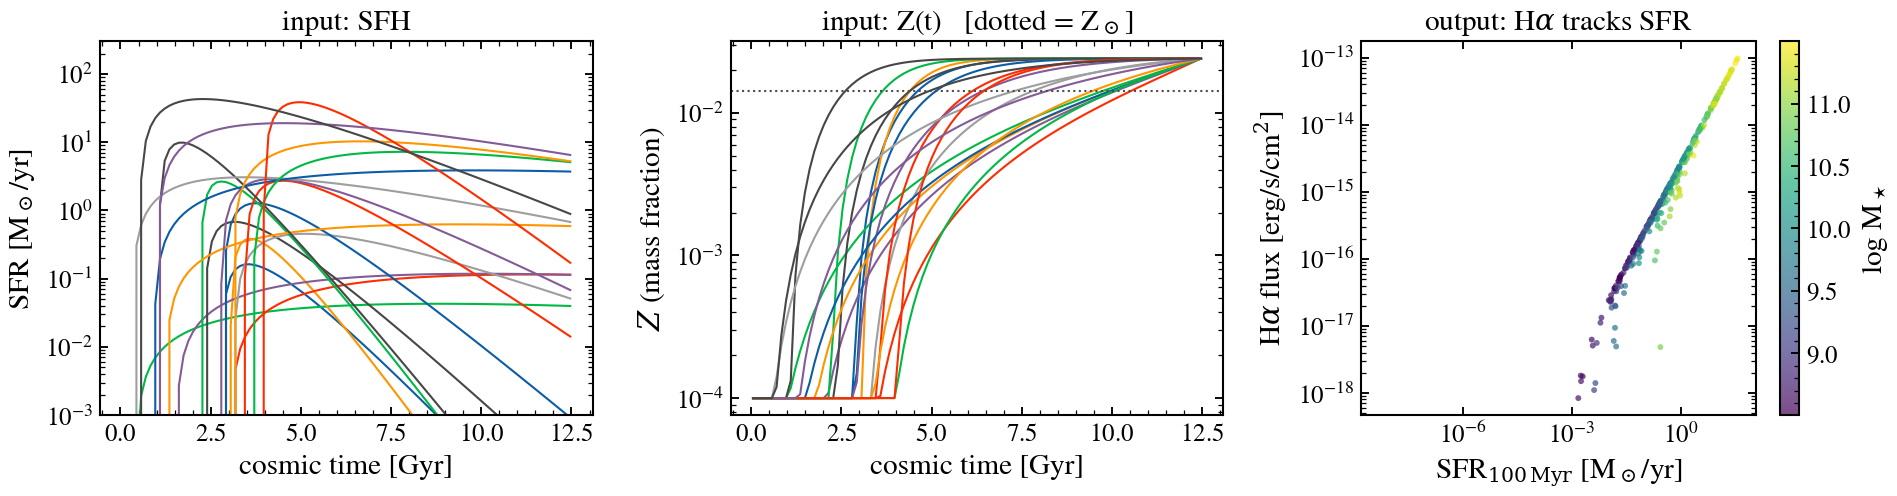

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

axes[0].plot(snap["t_gyr"], snap["sfr"][np.argsort(snap["log_mass"])[::25]].T, lw=1)
axes[0].set(
    xlabel="cosmic time [Gyr]",
    ylabel=r"SFR [M$_\odot$/yr]",
    yscale="log",
    ylim=(1e-3, 3e2),
    title="input: SFH",
)

axes[1].plot(snap["t_gyr"], met[np.argsort(snap["log_mass"])[::25]].T, lw=1)
axes[1].axhline(0.0142, color="0.3", ls=":", lw=1)
axes[1].set(
    xlabel="cosmic time [Gyr]",
    ylabel="$Z$ (mass fraction)",
    yscale="log",
    title=r"input: Z(t)   [dotted = Z$_\odot$]",
)

sc = axes[2].scatter(
    props["sfr_100myr"],
    lines["Halpha"],
    s=8,
    alpha=0.7,
    lw=0,
    c=snap["log_mass"],
    cmap="viridis",
)
axes[2].set(
    xscale="log",
    yscale="log",
    xlabel=r"SFR$_{100\,\rm Myr}$ [M$_\odot$/yr]",
    ylabel=r"H$\alpha$ flux [erg/s/cm$^2$]",
    title=r"output: H$\alpha$ tracks SFR",
)
fig.colorbar(sc, ax=axes[2], label=r"log M$_\star$")
fig.tight_layout()
fig.savefig(FIG_DIR / "12_in_out.png", dpi=140)
plt.show()

## 4. Vectorizing it yourself

`Catalog` is convenient, but if you are wiring this into your own pipeline you
want the `vmap` directly. **The parameter dict is a pytree, and `vmap` maps the
leading axis of every leaf** — scalars and histories batch through the same call:

```python
{"sfh_t_gyr": (N, n_t),      # a history
 "sfh_sfr":   (N, n_t),      # a history
 "met_history": (N, n_t),    # a history
 "dust_tau_diff": (N,)}      # a per-galaxy scalar
```

Here are the columns `Catalog` builds:

In [6]:
columns = {k: np.asarray(v) for k, v in cat._history_columns.items()}
for k, v in columns.items():
    print(f"   {k:16s} {v.shape}")

one = {k: v[0] for k, v in columns.items()}  # a single galaxy
batch = {k: v[:256] for k, v in columns.items()}  # 256 of them
K = 256

   sfh_t_gyr        (500, 96)
   sfh_sfr          (500, 96)
   met_history      (500, 96)


Four ways to run it.

In [7]:


def bench(fn, arg, n, reps=7):
    """First-call seconds, and best warm ms/galaxy over `reps`."""
    t0 = time.perf_counter()
    jax.block_until_ready(fn(arg))  # compile happens here
    first = time.perf_counter() - t0
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(arg))
        ts.append(time.perf_counter() - t0)
    return first, min(ts) / n


# (a) one galaxy at a time
first_one, t_one = bench(jax.jit(fwd.predict_photometry), one, 1, reps=30)

# (b) vmap alone -- vectorized, but NOT compiled as one program
first_vmap, t_vmap = bench(jax.vmap(fwd.predict_photometry), batch, K)

# (c) jit(vmap(...)) -- this is the one you want
f_jitvmap = jax.jit(jax.vmap(fwd.predict_photometry))
first_jitvmap, t_jitvmap = bench(f_jitvmap, batch, K)

# (d) Catalog: (c) plus chunking, padding, and a cross-call compile cache
cat_k = Catalog.from_histories(
    fwd, t_gyr=snap["t_gyr"], sfr=snap["sfr"][:K], met=met[:K], met_unit="z_mass_fraction"
)
cat_k.predict(chunk_size=K)
t0 = time.perf_counter()
cat_k.predict(chunk_size=K)
t_cat = (time.perf_counter() - t0) / K

print(f"{'':34s}{'first call':>12s}{'ms/galaxy':>11s}{'galaxies/s':>13s}")
for label, first, t in (
    ("(a) jit, one galaxy", first_one, t_one),
    ("(b) vmap without jit", first_vmap, t_vmap),
    ("(c) jit(vmap(...))", first_jitvmap, t_jitvmap),
    ("(d) Catalog.predict", float("nan"), t_cat),
):
    fc = "  -" if first != first else f"{first:9.2f} s"
    print(f"  {label:32s}{fc:>12s}{1e3 * t:10.3f}{1 / t:13.0f}")
print(f"\n  (a) -> (c)  vectorizing wins {t_one / t_jitvmap:.1f}x on throughput")
print(f"  (b) -> (c)  jit-ing the vmap costs {first_vmap / first_jitvmap:.1f}x less on the")
print("              first call, and never costs you throughput")

                                    first call  ms/galaxy   galaxies/s
  (a) jit, one galaxy                   0.44 s     0.206         4844
  (b) vmap without jit                  0.65 s     0.095        10567
  (c) jit(vmap(...))                    0.44 s     0.079        12621
  (d) Catalog.predict                        -     0.094        10630

  (a) -> (c)  vectorizing wins 2.6x on throughput
  (b) -> (c)  jit-ing the vmap costs 1.5x less on the
              first call, and never costs you throughput


**Every distinct batch width is its own compile.** JAX keys its cache on
shape, so a ragged trailing chunk — 128, 128, 47 — compiles the program
twice. Pad to a uniform width:

In [8]:
for width in (100, 99):
    sub = {k: v[:width] for k, v in columns.items()}
    t0 = time.perf_counter()
    jax.block_until_ready(f_jitvmap(sub))
    print(f"   first call at width {width:4d}: {time.perf_counter() - t0:5.2f} s  (a compile)")
print("\n   -> two widths, two compiles. Catalog.predict pads for you; if you")
print("      roll your own, pad the last chunk and discard the extra rows.")

   first call at width  100:  0.57 s  (a compile)


   first call at width   99:  0.56 s  (a compile)

   -> two widths, two compiles. Catalog.predict pads for you; if you
      roll your own, pad the last chunk and discard the extra rows.


### How wide can the vmap go?

$$ \text{max width} \;\approx\; \frac{\text{RAM you can spare}}{\text{MB per galaxy}} $$

In [9]:
_RSS_SCALE = 1.0 if sys.platform == "darwin" else 1024.0  # bytes on macOS, kB on Linux


def peak_rss_gb():
    """Peak resident set size so far, in GB. Monotonic: a high-water mark."""
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss * _RSS_SCALE / 1024**3


MAX_WIDTH = 1024  # deliberately modest: this notebook must not OOM its reader
wide = simulation_snapshot(MAX_WIDTH, seed=23)
wide_cols = {
    "sfh_t_gyr": np.tile(wide["t_gyr"], (MAX_WIDTH, 1)),
    "sfh_sfr": wide["sfr"],
    "met_history": np.log10(np.maximum(wide["met"], Z_FLOOR)) + 1.848,
}

print(f"baseline peak RSS {peak_rss_gb():.2f} GB")
print(f"{'width':>7s}{'peak GB':>10s}{'marginal MB/galaxy':>21s}{'ms/galaxy':>11s}")

marginals, prev_w, prev_rss = [], 0, peak_rss_gb()
for width in (64, 256, MAX_WIDTH):
    sub = {k: v[:width] for k, v in wide_cols.items()}
    jax.block_until_ready(f_jitvmap(sub))
    t0 = time.perf_counter()
    jax.block_until_ready(f_jitvmap(sub))
    dt = time.perf_counter() - t0
    now = peak_rss_gb()
    marginal = 1024 * (now - prev_rss) / (width - prev_w)
    if marginal > 0:
        marginals.append(marginal)
    print(f"{width:7d}{now:10.2f}{marginal:21.2f}{1e3 * dt / width:11.3f}")
    prev_w, prev_rss = width, now


# Peak RSS is a high-water mark, so a width that fits inside memory the process
# has already claimed reports no growth at all — and on a loaded machine every
# width can, which leaves nothing to take a slope from. Ask the compiled program
# instead: XLA reports the scratch it will allocate, exactly, and that number
# does not move when the machine is busy.
def scratch_mb_per_galaxy(fn, columns, k=64):
    """Scratch memory one vmapped galaxy costs [MB], from the executable."""
    batch = {key: v[:k] for key, v in columns.items()}
    exe = fn.lower(batch).compile()
    return exe.memory_analysis().temp_size_in_bytes / k / 1024**2


mb_per_galaxy = scratch_mb_per_galaxy(f_jitvmap, wide_cols)
print(f"\n  -> {mb_per_galaxy:.3f} MB/galaxy   (memory_analysis, exact)")
if marginals:
    print(f"     RSS-derived estimate, for comparison: {marginals[-1]:.2f} MB/galaxy")
else:
    print("     RSS showed no growth at any width — it all fit under memory the")
    print("     process had already claimed. That is why the exact number wins.")
for budget in (2, 8, 32):
    print(
        f"     {budget:2d} GB of headroom  ->  batch up to ~{int(1024 * budget / mb_per_galaxy):,}"
    )

baseline peak RSS 2.42 GB
  width   peak GB   marginal MB/galaxy  ms/galaxy


     64      2.44                 0.26      0.098
    256      2.44                 0.00      0.081


   1024      3.32                 1.17      0.080

  -> 0.432 MB/galaxy   (memory_analysis, exact)
     RSS-derived estimate, for comparison: 1.17 MB/galaxy
      2 GB of headroom  ->  batch up to ~4,743
      8 GB of headroom  ->  batch up to ~18,973
     32 GB of headroom  ->  batch up to ~75,894


On this configuration a galaxy costs well under a megabyte, so a few GB holds
**tens of thousands** of them in a single `vmap` — for most catalogs you never
need to chunk at all. That is not a property of `vmap`; it is a property of
the *fast configuration*. Section 5 shows the same measurement on the heavy
one, where a galaxy costs about ten times more and the ceiling drops with it.

**What running out looks like.** Nothing useful. The OS `SIGKILL`s the process,
so you get no Python traceback, no `MemoryError`, no stack — just a dead
kernel, or a shell reporting exit code `-9` (or 137). If a run dies silently,
that is almost always this, and the fix is a smaller batch, not a bug hunt.

## 5. The optimization ladder

### 5a. The nebular backend is the biggest single lever

In [10]:
bench_snap = simulation_snapshot(256, seed=5)
bench_met = np.maximum(bench_snap["met"], Z_FLOOR)


def throughput(model, n=256, chunk=128, reps=5, gas=False):
    """Warm ms/galaxy for a whole catalog through `model`.

    ``gas=True`` feeds the gas-phase metallicity a live backend expects; a
    baked-in one refuses it, since its nebular grid already fixed that.
    """
    c = Catalog.from_histories(
        model,
        t_gyr=bench_snap["t_gyr"],
        sfr=bench_snap["sfr"][:n],
        met=bench_met[:n],
        met_gas=bench_met[:n, -1] if gas else None,
        met_unit="z_mass_fraction",
    )
    c.predict(chunk_size=chunk)
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter()
        c.predict(chunk_size=chunk)
        ts.append(time.perf_counter() - t0)
    return min(ts) / n


ssp_bare = tengri.load_ssp(download=True)  # bare-stellar, required by Cloudy


def build_cloudy():
    sed = SEDModel.build(
        ssp_data=ssp_bare,
        observation=Observation(photometry=phot),
        redshift=Fixed(Z_OBS),
        sfh={"type": "table"},
        met={"type": "table"},
        dust_attenuation={"type": "two_component", "law": "calzetti", "*": FIXED},
        neb={"type": "cloudy"},
        approx=WavePrecomp(),
    )
    return ForwardModel.build(sed=sed)


BENCH_N = 128  # keep the heavy configurations small enough to be safe

t_baked = throughput(fwd, n=BENCH_N)

# RSS is a high-water mark, and Cloudy will exceed everything measured so far,
# so the growth from here is attributable to it. Build it, measure it, and drop
# it again -- two heavy models resident at once is what pushes a laptop over.
before_cloudy = peak_rss_gb()
cloudy_model = build_cloudy()
t_cloudy = throughput(cloudy_model, n=BENCH_N, gas=True)
cloudy_mb_per_galaxy = 1024 * (peak_rss_gb() - before_cloudy) / BENCH_N
del cloudy_model
gc.collect()

print(
    f"  neb='ssp'    (baked into the SSP) {1e3 * t_baked:7.3f} ms/gal {1 / t_baked:9.0f} gal/s"
    f"   {mb_per_galaxy:6.2f} MB/gal"
)
print(
    f"  neb='cloudy' (live photoionization){1e3 * t_cloudy:6.3f} ms/gal {1 / t_cloudy:9.0f} gal/s"
    f"   {cloudy_mb_per_galaxy:6.2f} MB/gal"
)
print(
    f"\n  baked-in is {t_cloudy / t_baked:.0f}x faster and "
    f"{cloudy_mb_per_galaxy / mb_per_galaxy:.0f}x lighter."
)

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_89400/2665342662.py:32: DefaultFixedParametersWarning: Group 'met' states no 'all_params' disposition, so its remaining parameter was fixed at declared defaults:
  met_alpha_fe=0

To fit them, pass 'all_params': FREE:
  met={'all_params': FREE, ...}
To keep them fixed and silence this warning, say so explicitly:
  met={'all_params': FIXED, ...}
  sed = SEDModel.build(
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_89400/2665342662.py:32: DefaultFixedParametersWarning: Group 'neb' states no 'all_params' disposition, so its remaining 8 parameters were fixed at declared defaults:
  neb_dig_delta_logU=-1, neb_dig_frac=0, neb_eline_sigma_kms=100, neb_fdust=0, neb_fesc=0, neb_fesc_lya=0, neb_logU=-3, neb_logZ_gas=-0.3

To fit them, pass 'all_params': FREE:
  neb={'all_params': FREE, ...}
To keep them fixed and silence this warning, say so explicitly:
  neb={'all_params': FIXED, ...}
  sed = SEDModel.build(
src/tengri/forw

  neb='ssp'    (baked into the SSP)   0.087 ms/gal     11478 gal/s     0.43 MB/gal
  neb='cloudy' (live photoionization) 3.951 ms/gal       253 gal/s    25.83 MB/gal

  baked-in is 45x faster and 60x lighter.


Make this choice first, and note it is a physics choice, not a tuning knob.
Baked-in fixes the gas-phase metallicity and ionization parameter when the
grid was built; a live backend makes them per-galaxy inputs and adds
intrinsic line luminosities. If measured line fluxes and broadband colors
are what you need, baked-in is both the right answer and the fast one.

The memory column is the part people get caught by. The same choice that
costs you an order of magnitude in speed costs you roughly an order of
magnitude in *footprint*, which moves the batch ceiling by the same factor:
a batch width that is comfortable on the baked-in path is an OOM kill on the
live one. Measured here at width 2048, the live path wanted about 19 GB and
was `SIGKILL`ed on a machine with 17 GB free — no traceback, exit -9.

### 5b. `WavePrecomp`

The exact path integrates the SSP x filter product on the full wavelength
grid on every call. `WavePrecomp` tabulates that once at build time and
interpolates. It costs a slower build and repays it on every evaluation.

In [11]:
exact_model = build_model(approx=None)
t_exact = throughput(exact_model, n=BENCH_N)
del exact_model
gc.collect()
print(f"  approx=None          (exact grid) {1e3 * t_exact:7.3f} ms/gal {1 / t_exact:9.0f} gal/s")
print(
    f"  approx=WavePrecomp() (SSP x filter LUT) {1e3 * t_baked:6.3f} ms/gal "
    f"{1 / t_baked:9.0f} gal/s"
)
print(f"\n  WavePrecomp is {t_exact / t_baked:.1f}x faster.")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_89400/722251314.py:21: DefaultFixedParametersWarning: Group 'met' states no 'all_params' disposition, so its remaining parameter was fixed at declared defaults:
  met_alpha_fe=0

To fit them, pass 'all_params': FREE:
  met={'all_params': FREE, ...}
To keep them fixed and silence this warning, say so explicitly:
  met={'all_params': FIXED, ...}
  sed = SEDModel.build(


  approx=None          (exact grid)   3.821 ms/gal       262 gal/s
  approx=WavePrecomp() (SSP x filter LUT)  0.087 ms/gal     11478 gal/s

  WavePrecomp is 43.9x faster.


Note how the two levers interact. On the baked-in configuration `WavePrecomp`
is worth a large factor, because the SSP x filter integral is then most of the
remaining work. Put a live nebular emulator back in and the same `WavePrecomp`
is worth only about 2x — not because it got worse, but because the emulator
now dominates. **Optimize the biggest term first**, and re-measure after each
change rather than assuming the factors multiply.

### 5c. Batch width and scaling

In [12]:
print(f"{'chunk_size':>11s}{'ms/galaxy':>12s}{'galaxies/s':>13s}")
for chunk in (32, 64, 128, 256):
    t = throughput(fwd, n=256, chunk=chunk)
    print(f"{chunk:11d}{1e3 * t:11.3f}{1 / t:13.0f}")

print()
print(f"{'N':>8s}{'wall':>9s}{'ms/galaxy':>12s}{'galaxies/s':>13s}")
for n in (256, 1024, 4096):
    s = simulation_snapshot(n, seed=17)
    c = Catalog.from_histories(
        fwd,
        t_gyr=s["t_gyr"],
        sfr=s["sfr"],
        met=np.maximum(s["met"], Z_FLOOR),
        met_unit="z_mass_fraction",
    )
    c.predict(chunk_size=128)  # compile
    runs = []
    for _ in range(3):  # best-of-3: a shared machine adds noise, never speed
        t0 = time.perf_counter()
        c.predict(chunk_size=128)
        runs.append(time.perf_counter() - t0)
    dt = min(runs)
    print(f"{n:8d}{dt:8.2f}s{1e3 * dt / n:11.3f}{n / dt:13.0f}")

 chunk_size   ms/galaxy   galaxies/s


         32      0.118         8469


         64      0.102         9828
        128      0.089        11293


        256      0.082        12178

       N     wall   ms/galaxy   galaxies/s
     256    0.02s      0.089        11212


    1024    0.09s      0.089        11294


    4096    0.37s      0.089        11210


Per-galaxy cost is flat in *N*, so a bigger catalog is just proportionally
more wall clock. `chunk_size` trades memory for throughput **linearly** —
each vmapped galaxy carries its own SFH and Z(t) through the SSP machinery.
Section 4 measured that trade exactly, so size the chunk from your memory
budget rather than bisecting until something dies. If a run dies with no
Python traceback, memory is the first thing to suspect.

Per-galaxy *work* is flat to 0.2 % from *N* = 256 to 8192 (1.301 to 1.303 MFLOP/galaxy).

### 5d. `float32`

The last lever is precision, and it is the one whose payoff is most often
misdescribed. `tengri` turns float64 on at import because the projection to
flux needs the dynamic range — `d_L^2` at any interesting redshift overflows
float32 outright. What makes float32 usable anyway is that the forward model
never *forms* `d_L^2`: `observation/redshift_kernel.py` applies
$(1+z)/(4\pi d_L^2)$ as a log10 offset, precisely so that intermediate cannot
overflow. The dynamic range never exists as a number, so it never has to fit.

The switch is global, and it only affects arrays created after it — so it has
to come **before** the build. A model built under float64 keeps its float64
tables no matter what you set afterwards.

Two routes set it: `JAX_ENABLE_X64=0` in the environment *before* importing
tengri, or `jax.config.update` afterwards. In a notebook the import has
already happened, so it is the second one — the cell below. Either way,
**check the dtype you got rather than the dtype you asked for**; the cell
prints it, because a precision measurement that cannot fail is not a
measurement.

Rebuilding then emits a `UserWarning` per table — *"Explicitly requested dtype
float64 ... will be truncated to float32"*. That is JAX reporting the thing you
just asked for, not a problem; the cell silences it so the output stays
readable, and checks the resulting dtype instead of trusting it.

In [13]:


def program_cost(fn, arg):
    """FLOPs, bytes moved, and loop/fusion structure of the compiled program.

    Deterministic, unlike wall clock: it does not depend on what else the
    machine happens to be running.
    """
    exe = fn.lower(arg).compile()
    c = exe.cost_analysis()
    if isinstance(c, list):
        c = c[0]
    hlo = exe.as_text()
    return {
        "flops": c["flops"],
        "bytes": c["bytes accessed"],
        "while": hlo.count(" while("),
        "fusion": hlo.count("fusion("),
    }


f64_fn = jax.jit(jax.vmap(fwd.predict_photometry))
ref64 = np.asarray(f64_fn(batch))
c64 = program_cost(f64_fn, batch)

jax.config.update("jax_enable_x64", False)  # global, and BEFORE the build

with warnings.catch_warnings():
    # The SSP tables ask for float64 explicitly; with x64 off JAX truncates them
    # and says so, once per table. Here that truncation is the entire point.
    warnings.filterwarnings("ignore", message=".*Explicitly requested dtype float64.*")
    fwd32 = build_model()
    batch32 = {k: v.astype(np.float32) for k, v in batch.items()}
    f32_fn = jax.jit(jax.vmap(fwd32.predict_photometry))
    out32 = np.asarray(f32_fn(batch32))
    c32 = program_cost(f32_fn, batch32)

dmag = np.abs(-2.5 * (np.log10(out32) - np.log10(ref64)))
print(f"  {'':18s}{'float64':>12s}{'float32':>12s}{'ratio':>10s}")
print(f"  {'output dtype':18s}{ref64.dtype!s:>12s}{out32.dtype!s:>12s}")
print(
    f"  {'FLOPs [M]':18s}{c64['flops'] / 1e6:12.1f}{c32['flops'] / 1e6:12.1f}"
    f"{c64['flops'] / c32['flops']:9.2f}x"
)
print(
    f"  {'bytes moved [MB]':18s}{c64['bytes'] / 1e6:12.1f}{c32['bytes'] / 1e6:12.1f}"
    f"{c64['bytes'] / c32['bytes']:9.2f}x"
)
print(f"  {'while loops':18s}{c64['while']:12d}{c32['while']:12d}")
print(f"  {'fusion regions':18s}{c64['fusion']:12d}{c32['fusion']:12d}")
print(f"\n  agreement with float64: median {np.median(dmag):.0e} mag, worst {dmag.max():.0e} mag")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_89400/722251314.py:21: DefaultFixedParametersWarning: Group 'met' states no 'all_params' disposition, so its remaining parameter was fixed at declared defaults:
  met_alpha_fe=0

To fit them, pass 'all_params': FREE:
  met={'all_params': FREE, ...}
To keep them fixed and silence this warning, say so explicitly:
  met={'all_params': FIXED, ...}
  sed = SEDModel.build(


                         float64     float32     ratio
  output dtype           float64     float32
  FLOPs [M]                328.0       327.9     1.00x
  bytes moved [MB]         715.8       394.6     1.81x
  while loops                  7           7
  fusion regions             141         138

  agreement with float64: median 1e-05 mag, worst 3e-04 mag


Read that table carefully, because it says something more useful than
"float32 is faster".

**The FLOP count does not move.** Same arithmetic, same number of `while`
loops, same number of fusion regions — the compiled program has the same
shape, it is just narrower. float32 is not buying you arithmetic here.

**The bytes halve.** About 1.8x fewer bytes moved, and roughly 1.9x less
scratch memory. This workload is bandwidth-bound rather than FLOP-bound, so
bytes are the currency that matters — which means the dependable win is the
**batch ceiling** from section 4, not the clock. Close to twice the width
fits in the same RAM.

**Whether that becomes speed depends on your machine.**

Two traps, both measured rather than imagined:

**Underflow at high redshift.** Agreement holds at ~1e-5 mag from z = 0.01 to
z = 3. At z = 6 the Lyman-break dropout bands are genuinely tiny — float64
returns 1e-49 to 1e-41 there — and float32 has no such numbers, so they come
back as exactly `0.0` (measured: 128 of 352 fluxes). Those bands are dark
either way, but `0.0` turns a color or a log into `-inf`. Above z ~ 4, stay in
float64 or mask the dropouts deliberately.

float32's smallest subnormal is 1.4e-45, so any constant below that *is* zero
there — and a zero that multiplies is not a rounding error, it is a wrong
answer. If you write your own float32 path, reach for
`tengri.utils.scale.representable_floor` rather than a bare literal: it lifts
a floor to the working dtype's smallest normal and leaves float64 alone.

**Grid edges stop being exact.** `Z_FLOOR` above is read off the SSP
metallicity grid and clipped *to* it. In float32 that edge is only good to
~1e-7 relative, so a value clipped exactly onto it can land a hair outside,
and `Catalog.from_histories` then refuses the whole catalog — correctly, since
off-grid nodes are clipped silently inside JIT. Clip with a margin
(`Z_FLOOR * (1 + 1e-4)`) instead of to the edge itself.

Finally, scope this. Everything above measures `predict_photometry` on the
baked-in nebular configuration from section 5a. It does not transfer for free:
a different component brings its own small constants, and the CB19 line list
once returned *every* line as exactly zero in pure float32 for precisely the
reason above. Re-run this comparison after changing the component stack rather
than assuming the result carries over. Inference is a separate question again
— gradients, mass matrices and log-likelihood *differences* have their own
conditioning, and nothing here measures any of it.

## The whole thing

```python
import numpy as np, tengri
from tengri import (Catalog, Fixed, FIXED, ForwardModel, Observation,
                    Photometry, SEDModel, WavePrecomp)

ssp = tengri.load_ssp("prsc_miles_chabrier_wNE", download=True)
obs = Observation(photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r"]))

fwd = ForwardModel.build(sed=SEDModel.build(
    ssp_data=ssp, observation=obs, redshift=Fixed(0.1),
    sfh={"type": "table"}, met={"type": "table"},
    dust_attenuation={"type": "two_component", "law": "calzetti",
                      "all_params": FIXED},
    neb={"type": "ssp"}, approx=WavePrecomp(),
))

cat = Catalog.from_histories(fwd, t_gyr=t, sfr=sfr, met=Z,
                             met_unit="z_mass_fraction")
mock = cat.simulate(lines=("Halpha", "OIII_5007"),
                    properties=("stellar_mass", "sfr_100myr"), chunk_size=128)
mock.photometry            # (N, n_bands)  erg/s/cm2/Hz
mock.lines["Halpha"]       # (N,)          erg/s/cm2
mock.to_table()
```

Per-galaxy scalars ride along with `params={"dust_tau_diff": tau}`; per-galaxy
redshifts need `redshift=` plus a `WavePrecomp(catalog_z_range=(zmin, zmax))`
so the program still compiles once.